# Kapitel 4 – Induktive Statistik

Begleitendes Notebook zum Vorlesungsskript. Die Beispiele illustrieren:
1. Stichprobenverteilung des Mittelwerts $\bar{X}$
2. Chi-Quadrat-Verteilung und Verteilung von $\frac{(n-1)S^2}{\sigma^2}$
3. t-Verteilung im Vergleich zur Standardnormalverteilung
4. Verteilung des Stichprobenanteils $\hat{p}$

Alle Parameter sind frei anpassbar.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['mathtext.fontset'] = 'cm'
rng = np.random.default_rng(42)

## 1. Verteilung des Stichprobenmittelwerts $\bar{X}$

Wir ziehen viele Stichproben vom Umfang $n$ aus einer Grundgesamtheit mit Erwartungswert $\mu$ und Varianz $\sigma^2$.
Theorie: $\bar{X} \sim N(\mu,\, \sigma^2/n)$ (exakt bei normalverteilter Grundgesamtheit, näherungsweise sonst).

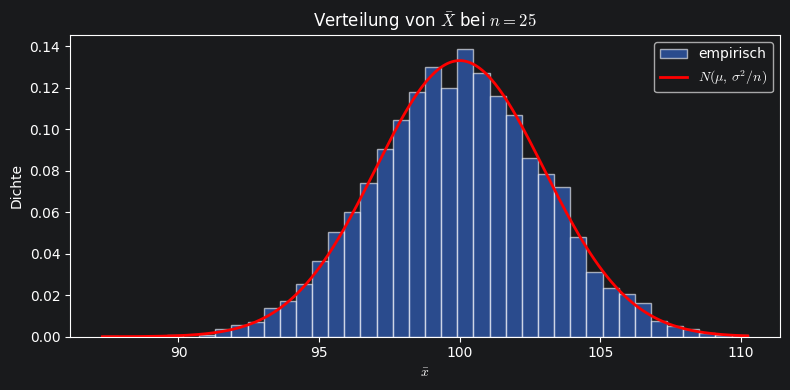

Empirisch: Mittel=99.948, SD=3.028
Theorie:   Mittel=100.000, SD=3.000


In [2]:
# --- Parameter anpassen ---
mu, sigma = 100.0, 15.0
n = 25
anzahl_stichproben = 5000
# --------------------------

stichproben = rng.normal(mu, sigma, size=(anzahl_stichproben, n))
mittelwerte = stichproben.mean(axis=1)

fig, ax = plt.subplots(figsize=(8,4))
ax.hist(mittelwerte, bins=40, density=True, alpha=0.6, edgecolor='white', label='empirisch')
x = np.linspace(mittelwerte.min(), mittelwerte.max(), 300)
ax.plot(x, stats.norm.pdf(x, mu, sigma/np.sqrt(n)), 'r-', lw=2, label=fr'$N(\mu,\,\sigma^2/n)$')
ax.set_title(fr'Verteilung von $\bar{{X}}$ bei $n={n}$')
ax.set_xlabel(r'$\bar{x}$'); ax.set_ylabel('Dichte'); ax.legend()
plt.tight_layout(); plt.show()

print(f'Empirisch: Mittel={mittelwerte.mean():.3f}, SD={mittelwerte.std(ddof=1):.3f}')
print(f'Theorie:   Mittel={mu:.3f}, SD={sigma/np.sqrt(n):.3f}')

## 2. Chi-Quadrat-Verteilung und Stichprobenvarianz

Für eine normalverteilte Grundgesamtheit gilt: $\dfrac{(n-1)S^2}{\sigma^2} \sim \chi^2(n-1)$.

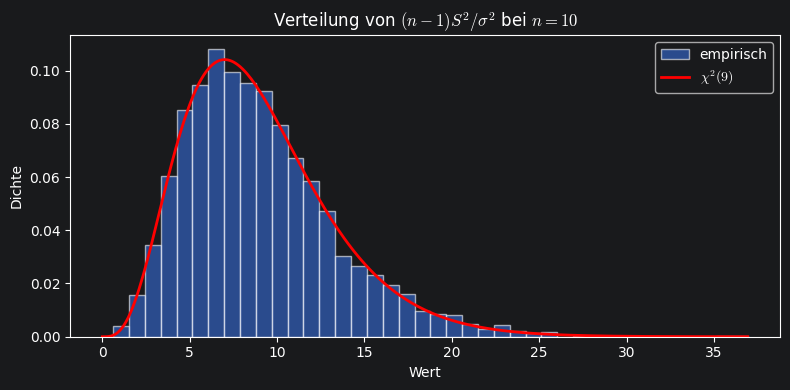

In [3]:
# --- Parameter anpassen ---
mu, sigma = 50.0, 4.0
n = 10
anzahl_stichproben = 5000
# --------------------------

stichproben = rng.normal(mu, sigma, size=(anzahl_stichproben, n))
S2 = stichproben.var(axis=1, ddof=1)
T = (n-1) * S2 / sigma**2

fig, ax = plt.subplots(figsize=(8,4))
ax.hist(T, bins=40, density=True, alpha=0.6, edgecolor='white', label='empirisch')
x = np.linspace(0, T.max(), 300)
ax.plot(x, stats.chi2.pdf(x, df=n-1), 'r-', lw=2, label=fr'$\chi^2({n-1})$')
ax.set_title(fr'Verteilung von $(n-1)S^2/\sigma^2$ bei $n={n}$')
ax.set_xlabel('Wert'); ax.set_ylabel('Dichte'); ax.legend()
plt.tight_layout(); plt.show()

## 3. t-Verteilung vs. Standardnormalverteilung

Bei unbekannter Varianz nutzen wir $T = \dfrac{\bar{X}-\mu}{S/\sqrt{n}} \sim t(n-1)$.
Mit wachsendem $n$ nähert sich $t(n-1)$ der $N(0,1)$ an.

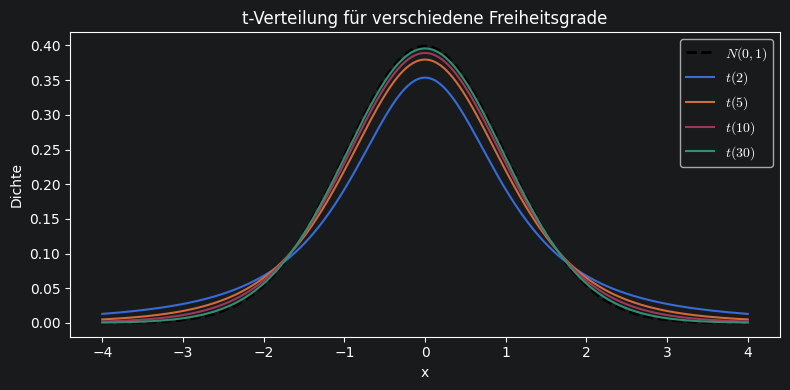

Ausläufer werden mit wachsendem df schlanker.


In [4]:
# --- Parameter anpassen ---
freiheitsgrade = [2, 5, 10, 30]
# --------------------------

x = np.linspace(-4, 4, 400)
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(x, stats.norm.pdf(x), 'k--', lw=2, label=r'$N(0,1)$')
for df in freiheitsgrade:
    ax.plot(x, stats.t.pdf(x, df=df), label=fr'$t({df})$')
ax.set_title('t-Verteilung für verschiedene Freiheitsgrade')
ax.set_xlabel('x'); ax.set_ylabel('Dichte'); ax.legend()
plt.tight_layout(); plt.show()

print('Ausläufer werden mit wachsendem df schlanker.')

## 4. Verteilung des Stichprobenanteils $\hat{p}$

Für $n\hat{p}(1-\hat{p}) \geq 9$ gilt näherungsweise $\hat{p} \sim N\!\left(p,\, \dfrac{p(1-p)}{n}\right)$.

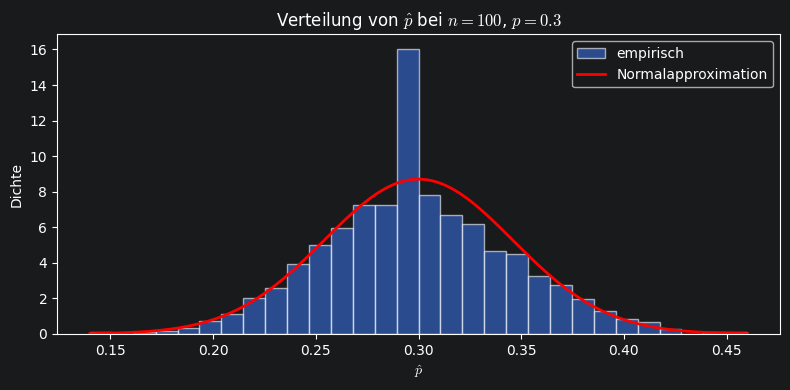

Faustregel n·p·(1-p) = 21.0  (≥ 9 erfüllt: True)


In [5]:
# --- Parameter anpassen ---
p = 0.3
n = 100
anzahl_stichproben = 5000
# --------------------------

p_hat = rng.binomial(n, p, size=anzahl_stichproben) / n

fig, ax = plt.subplots(figsize=(8,4))
ax.hist(p_hat, bins=30, density=True, alpha=0.6, edgecolor='white', label='empirisch')
x = np.linspace(p_hat.min(), p_hat.max(), 300)
ax.plot(x, stats.norm.pdf(x, p, np.sqrt(p*(1-p)/n)), 'r-', lw=2, label='Normalapproximation')
ax.set_title(fr'Verteilung von $\hat{{p}}$ bei $n={n}$, $p={p}$')
ax.set_xlabel(r'$\hat{p}$'); ax.set_ylabel('Dichte'); ax.legend()
plt.tight_layout(); plt.show()

print(f'Faustregel n·p·(1-p) = {n*p*(1-p):.1f}  (≥ 9 erfüllt: {n*p*(1-p) >= 9})')

## Aufgaben zum Ausprobieren

1. Setze in Abschnitt 1 $n=4$ und $n=100$. Wie verändert sich die Streuung von $\bar{X}$?
2. Wähle in Abschnitt 2 $n=3$ – wie schief ist die $\chi^2(2)$-Verteilung?
3. Ab welchem df ist $t(\text{df})$ optisch kaum noch von $N(0,1)$ zu unterscheiden?
4. Wähle in Abschnitt 4 $p=0{,}05$ und $n=30$. Ist die Normalapproximation noch gut?